In [5]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from random import shuffle
%matplotlib inline

In [2]:
def label_image(img):
  pet = img.split('.')[-3]
  if pet == 'cat': return 0
  elif pet == 'dog': return 1

In [4]:
import os

input_dir = "dogs-vs-cats/train/train"
output_dir = "dogs-vs-cats/train_processed" 

image_list = [f for f in os.listdir(input_dir) if f.endswith(".jpg")]

print(image_list[:5])  


['cat.0.jpg', 'cat.1.jpg', 'cat.10.jpg', 'cat.100.jpg', 'cat.1000.jpg']


In [5]:
def plot_image_folder_count(image_folder):
    labels = []
    for img in image_folder:
        label = img.split('.')[0]
        labels.append(label)

    # Chuyển list sang pandas Series
    labels_series = pd.Series(labels)

    sns.countplot(x=labels_series, orient='v')
    plt.title('Cats and Dogs')
    plt.show()

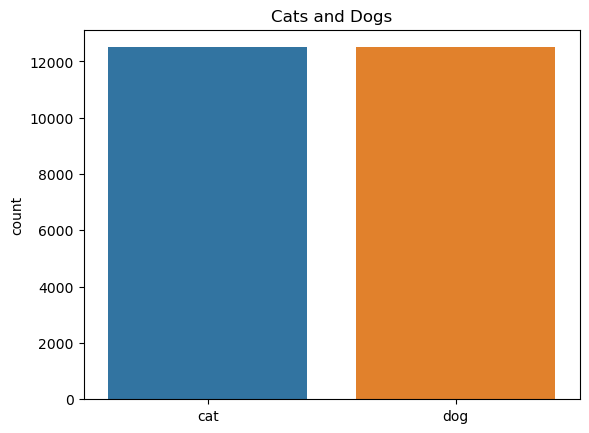

In [6]:
image_list = [f for f in os.listdir(input_dir) if f.endswith(".jpg")]

plot_image_folder_count(image_list)

In [7]:
def process_data(image_list, output):
    for img_filename in tqdm(image_list):
        label = label_image(img_filename)
        if label == -1:
            continue 

        img_path = os.path.join(input_dir, img_filename)
        img = Image.open(img_path)

        folder = 'cat' if label == 0 else 'dog'
        output_folder = os.path.join(output, folder)
        os.makedirs(output_folder, exist_ok=True)

        img.save(os.path.join(output_folder, img_filename))

# Gọi hàm chạy xử lý
process_data(image_list, output_dir)

100%|████████████████████████████████████████████████████████████████████████████| 25000/25000 [08:27<00:00, 49.22it/s]


In [9]:
train_data = input_dir   
image_list = [f for f in os.listdir(input_dir) if f.endswith('.jpg')]

train_data, test_data = train_test_split(image_list, test_size=0.2, random_state=42)

print("Số ảnh train:", len(train_data))
print("Số ảnh test:", len(test_data))

Số ảnh train: 20000
Số ảnh test: 5000


In [10]:
train_data, test_data = train_test_split(image_list, test_size=0.2, random_state=42)

In [11]:
test_data, val_data = train_test_split(test_data, test_size=0.5, random_state=42)

In [12]:
process_data(train_data, './data_split/train')
process_data(test_data, './data_split/test')
process_data(val_data, './data_split/val')

100%|██████████████████████████████████████████████████████████████████████████████| 2500/2500 [00:35<00:00, 71.20it/s]


In [13]:
process_data(train_data, './data_folder/train')
process_data(test_data, './data_folder/test')
process_data(val_data, './data_folder/val')

100%|██████████████████████████████████████████████████████████████████████████████| 2500/2500 [00:36<00:00, 69.10it/s]


In [15]:
train_cat_dir = './data_split/train/cat'
train_dog_dir = './data_split/train/dog'

test_cat_dir = './data_split/test/cat'
test_dog_dir = './data_split/test/dog'

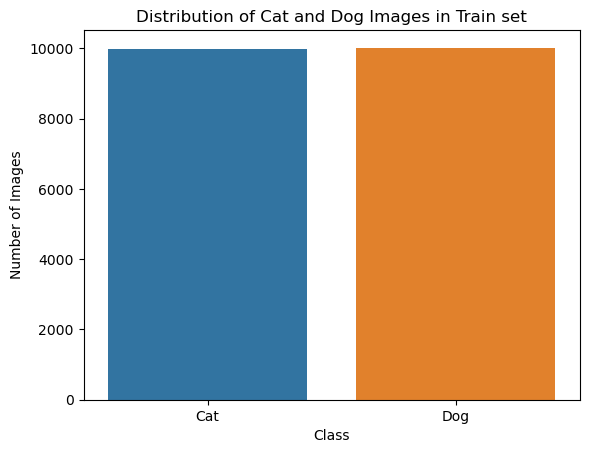

In [41]:
def visualize_distribution(cat_dir, dog_dir):
    num_train_cat = len(os.listdir(cat_dir))
    num_train_dog = len(os.listdir(dog_dir))

    data = pd.DataFrame({
        'Class': ['Cat', 'Dog'],
        'Count': [num_train_cat, num_train_dog]
    })

    sns.barplot(data=data, x='Class', y='Count')
    plt.title('Distribution of Cat and Dog Images in Train set')
    plt.xlabel('Class')
    plt.ylabel('Number of Images')
    plt.show()

visualize_distribution(train_cat_dir, train_dog_dir)

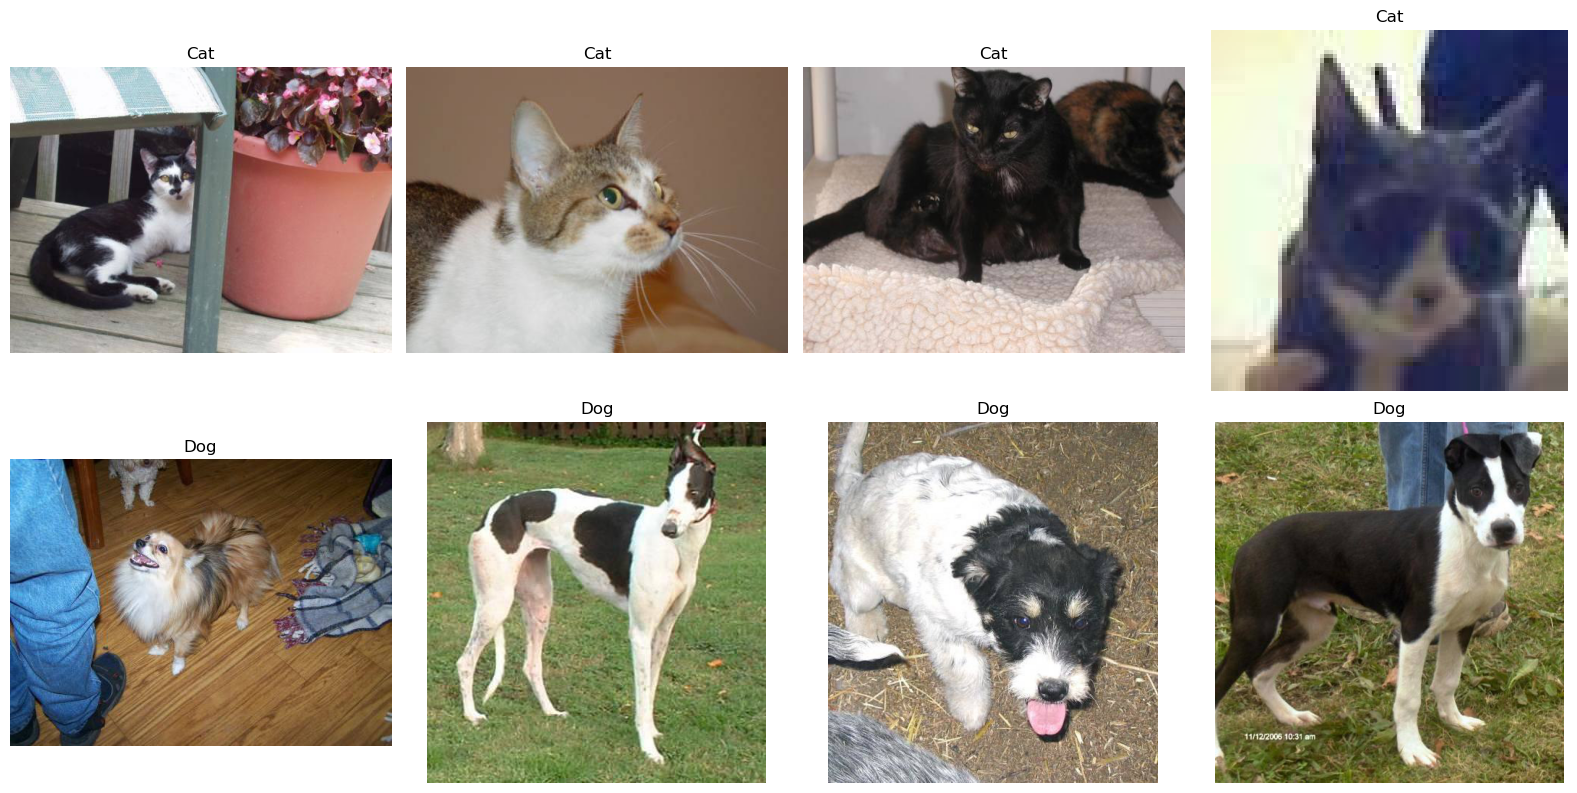

In [40]:
nrows = 2
ncols = 4

pic_index = 100  

train_cat_fnames = os.listdir(train_cats_dir)
train_dog_fnames = os.listdir(train_dogs_dir)

next_cat_pix = [os.path.join(train_cats_dir, fname) 
                for fname in train_cat_fnames[pic_index:pic_index+4]]

next_dog_pix = [os.path.join(train_dogs_dir, fname) 
                for fname in train_dog_fnames[pic_index:pic_index+4]]

plt.figure(figsize=(ncols * 4, nrows * 4))

for i, img_path in enumerate(next_cat_pix + next_dog_pix):
    plt.subplot(nrows, ncols, i + 1)
    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.title("Cat" if i < 4 else "Dog")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [12]:
from PIL import Image
import os

import pandas as pd
import matplotlib.pyplot as plt

In [13]:
cat_folder_path = './data_split/train/cat'
dog_folder_path = './data_split/train/dog'

In [14]:
def is_image(file_path):
    try:
        img = Image.open(file_path)
        img.verify()
        return True
    except Exception:
        return False

def get_image_info(folder_path):
    pic_info = {}
    for file_name in os.listdir(folder_path):
        path = os.path.join(folder_path, file_name)
        if os.path.isfile(path) and is_image(path):
            if file_name not in pic_info:
                img = Image.open(path)
                pic_info[file_name] = img.size
    return pic_info

In [15]:
def visualize_distribution(folder_path, label):
  pic_info = get_image_info(folder_path)
  widths = [shape[0] for shape in pic_info.values()]
  heights = [shape[1] for shape in pic_info.values()]

  df = pd.DataFrame({'width': widths, 'height': heights})
  print(f"Summary statistics for {label} images:")
  print(df.describe())

  df.hist(column=['width', 'height'], bins=30, color='blue', alpha=0.7, figsize=(10, 5))
  plt.suptitle(f'Distribution of {label} Images')
  plt.show()

Summary statistics for Cat images:
             width       height
count  9985.000000  9985.000000
mean    410.892138   357.677316
std     107.731038    96.279706
min      50.000000    32.000000
25%     335.000000   301.000000
50%     472.000000   374.000000
75%     499.000000   409.000000
max    1023.000000   768.000000


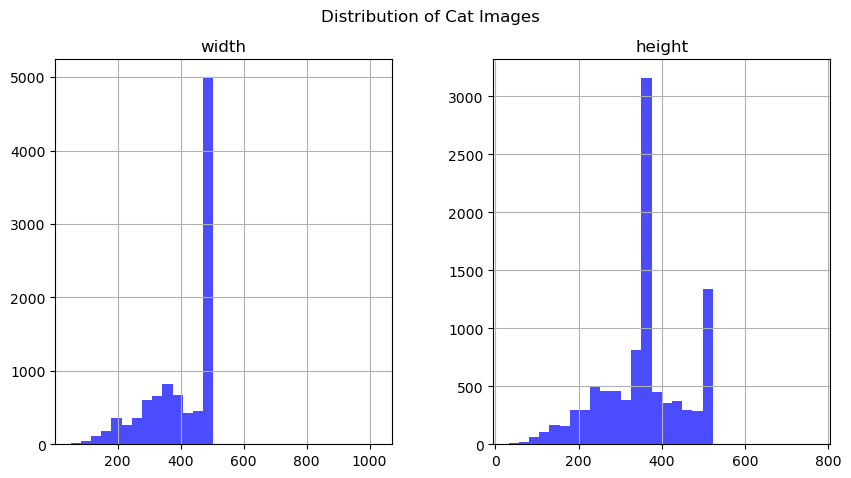

In [16]:
visualize_distribution(cat_folder_path, 'Cat')

Summary statistics for Dog images:
              width        height
count  10015.000000  10015.000000
mean     397.666600    365.019870
std      109.858472     97.202964
min       42.000000     33.000000
25%      319.000000    310.000000
50%      423.000000    374.000000
75%      499.000000    434.500000
max     1050.000000    702.000000


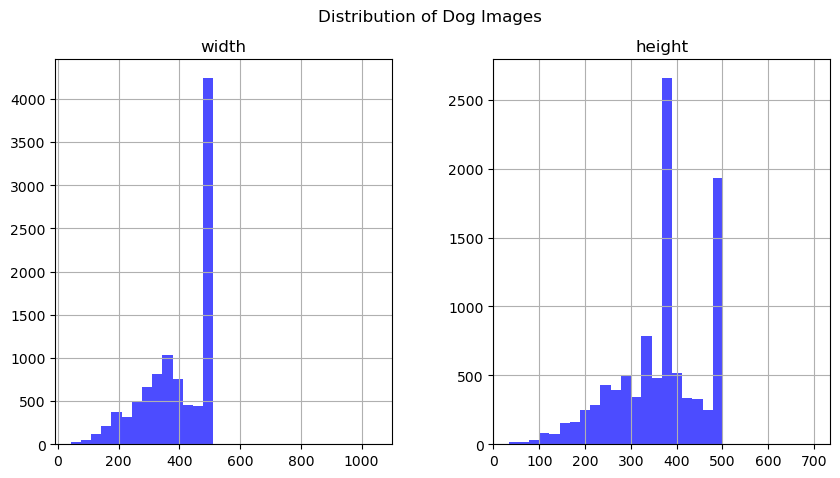

In [17]:
visualize_distribution(dog_folder_path, 'Dog')

In [18]:
def visualize_smallest_largest(folder_path, label):
  pic_info = get_image_info(folder_path)

  smallest_width_img = min(pic_info, key=lambda x: pic_info[x][0])
  largest_width_img = max(pic_info, key=lambda x: pic_info[x][0])

  fig, axs = plt.subplots(1, 2, figsize=(10, 6))

  smallest_img = mpimg.imread(os.path.join(folder_path, smallest_width_img))
  axs[0].imshow(smallest_img)
  axs[0].set_title(f"Smallest Width | {smallest_width_img}")

  largest_img = mpimg.imread(os.path.join(folder_path, largest_width_img))
  axs[1].imshow(largest_img)
  axs[1].set_title(f"Largest Width | {largest_width_img}")

  plt.suptitle(f'{label} Image: Smallest and Largest Width')
  plt.show()

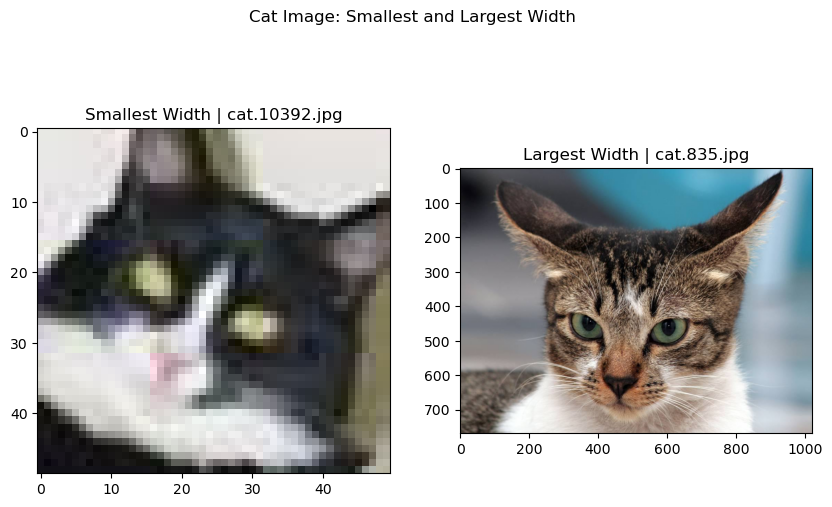

In [19]:
visualize_smallest_largest(cat_folder_path, 'Cat')

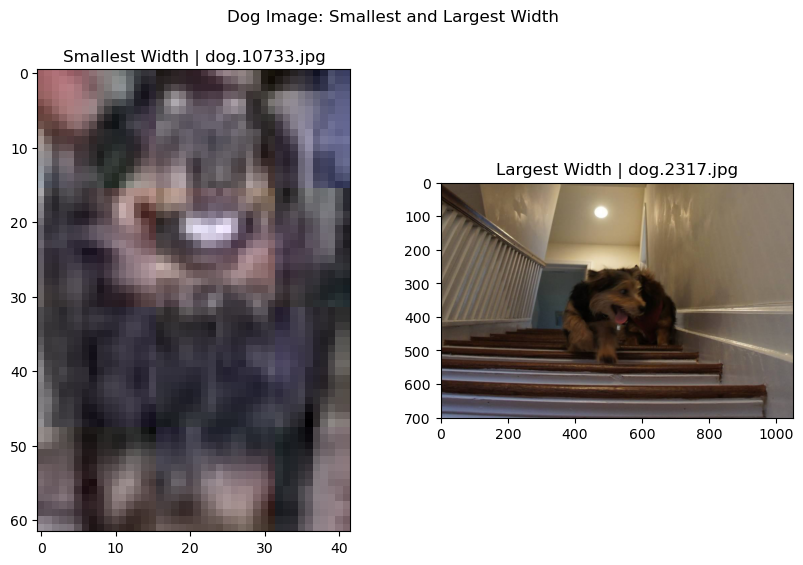

In [20]:
visualize_smallest_largest(dog_folder_path, 'Dog')

In [22]:
import cv2
import numpy as np

def preprocess_image_cv2(img_path, target_size=(128, 128)):
    img = cv2.imread(img_path)
    
    if img is None:
        raise FileNotFoundError(f"Không thể đọc ảnh tại đường dẫn: {img_path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, target_size)

    img = img / 255.0

    return img

img_path = r'C:\Users\thuuy\_python\ml\data_folder\test\cat\cat.10022.jpg'
img_processed = preprocess_image_cv2(img_path)
print(img_processed.shape)  
print(img_processed.min(), img_processed.max()) 


(128, 128, 3)
0.0 1.0
